# This Notebook Aims to Modify the Inputs

The updates will be performed initially on the 'clean_data.csv'

## Importing

In [1]:
from pathlib import Path
import sys
root= Path.cwd().parent
sys.path.append(str(root))
from src.graph import univariate_plot
from src.clean import log_transform,  standard_scaling, classification_formulation, binary_classification_formulation

import pandas as pd
import pickle

In [2]:
data = pd.read_csv('../data/processed/clean_data.csv')

## Adding New Features

Adding the input 'rooms_per_household'

In [3]:
data["rooms_per_household"] = data["total_rooms"] / data["households"]

Adding the input 'bedrooms_per_room', which is the proportion of bedrooms

In [4]:
data['bedrooms_per_room'] = data["total_bedrooms"] / data["total_rooms"]

Adding the input 'population_per_household', which is the proportion of bedrooms

In [5]:
data['population_per_household'] = data['population'] / data['households']

Reorder the columns to make the boolean columns last

In [6]:
data= data[
    list(data.columns[0:9]) +
    list(data.columns[14:]) +
    list(data.columns[9:14])
]

In [7]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,bedrooms_per_room,population_per_household,<1h ocean,inland,near ocean,island,rooms_per_household
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909,0.213794,3.070655,0.442636,0.317393,0.128779,0.000242,5.429000
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874,0.065248,10.386050,0.496710,0.465473,0.334963,0.015563,2.474173
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.037151,0.692308,0.000000,0.000000,0.000000,0.000000,0.846154
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000,0.175225,2.429741,0.000000,0.000000,0.000000,0.000000,4.440716
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,0.203159,2.818116,0.000000,0.000000,0.000000,0.000000,5.229129
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000,0.240126,3.282261,1.000000,1.000000,0.000000,0.000000,6.052381
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,2.824675,1243.333333,1.000000,1.000000,1.000000,1.000000,141.909091


Check a sample

In [8]:
data.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,bedrooms_per_room,population_per_household,<1h ocean,inland,near ocean,island,rooms_per_household
13458,-117.38,34.11,32.0,3179.0,662.0,1878.0,661.0,3.1375,101200.0,0.208242,2.841150,0,1,0,0,4.809380
3016,-118.93,34.82,8.0,508.0,111.0,229.0,84.0,4.0332,128300.0,0.218504,2.726190,0,1,0,0,6.047619
16758,-122.48,37.71,39.0,3615.0,632.0,1571.0,615.0,5.1149,314200.0,0.174827,2.554472,0,0,1,0,5.878049
14896,-117.07,32.60,18.0,2602.0,551.0,1042.0,550.0,1.9267,67500.0,0.211760,1.894545,0,0,1,0,4.730909
2584,-124.07,40.87,47.0,1765.0,326.0,796.0,333.0,2.2138,99200.0,0.184703,2.390390,0,0,1,0,5.300300


## Re-Visualize the Old Columns and Visualize Newer Ones as Histograms and BoxPlots

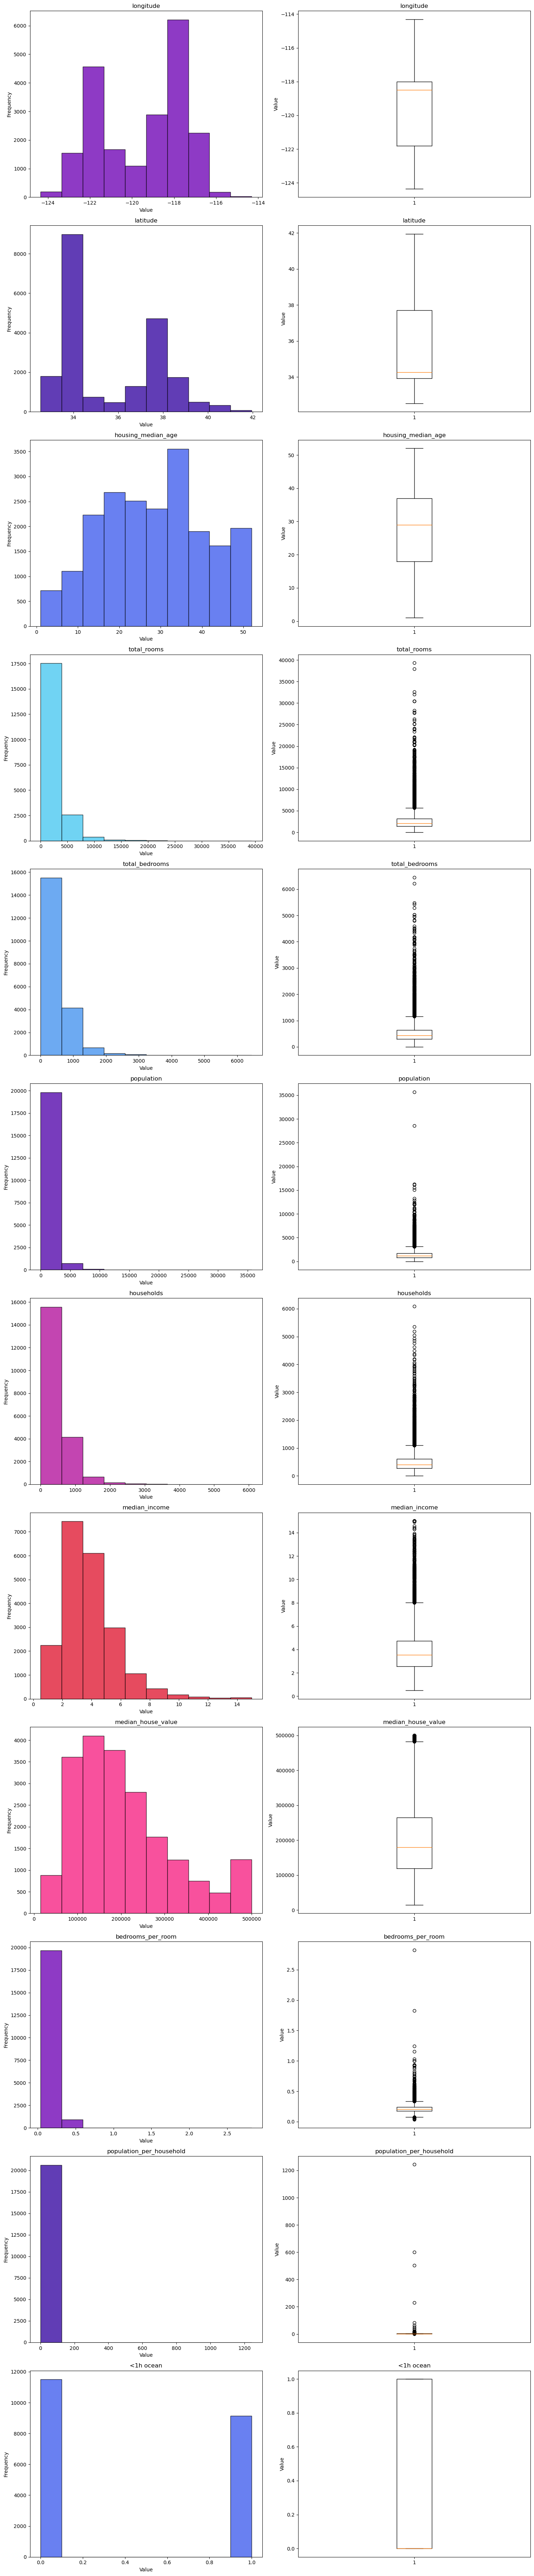

In [9]:
univariate_plot(data, 0, 12)

## Modifying the Skewed Columns using Log Transformation

In [10]:
data = log_transform(data, ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income'])

In [11]:
data.sample(5)

,longitude,latitude,housing_median_age,median_house_value,bedrooms_per_room,population_per_household,<1h ocean,inland,near ocean,island,rooms_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households,log_median_income
820,-122.07,37.63,24.0,177600.0,0.199657,3.092715,0,0,0,0,5.141280,7.753624,6.144186,7.245655,6.118097,1.721212
1142,-121.60,39.68,15.0,111200.0,0.205725,2.557576,0,1,0,0,5.081818,7.425358,5.846439,6.739337,5.802118,1.222539
19167,-122.71,38.42,23.0,129200.0,0.263862,2.801630,1,0,0,0,4.263587,7.358831,6.028279,6.939254,5.910797,0.965728
4686,-118.35,34.07,45.0,287500.0,0.276048,1.645762,1,0,0,0,3.823126,8.962392,7.675546,8.119696,7.621685,1.472334
12599,-121.49,38.53,42.0,124200.0,0.191417,2.107011,0,1,0,0,5.416974,7.292337,5.641907,6.349139,5.605802,1.479466


In [12]:
data.describe()

,longitude,latitude,housing_median_age,median_house_value,bedrooms_per_room,population_per_household,<1h ocean,inland,near ocean,island,rooms_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households,log_median_income
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,206855.816909,0.213794,3.070655,0.442636,0.317393,0.128779,0.000242,5.429000,7.629377,6.054938,7.025503,5.984702,1.516995
std,2.003532,2.135952,12.585558,115395.615874,0.065248,10.386050,0.496710,0.465473,0.334963,0.015563,2.474173,0.749991,0.723078,0.736238,0.726740,0.358677
min,-124.350000,32.540000,1.000000,14999.000000,0.037151,0.692308,0.000000,0.000000,0.000000,0.000000,0.846154,1.098612,0.693147,1.386294,0.693147,0.405398
25%,-121.800000,33.930000,18.000000,119600.000000,0.175225,2.429741,0.000000,0.000000,0.000000,0.000000,4.440716,7.278456,5.697093,6.669498,5.638355,1.270715
50%,-118.490000,34.260000,29.000000,179700.000000,0.203159,2.818116,0.000000,0.000000,0.000000,0.000000,5.229129,7.662938,6.077642,7.062192,6.016157,1.511781
75%,-118.010000,37.710000,37.000000,264725.000000,0.240126,3.282261,1.000000,1.000000,0.000000,0.000000,6.052381,8.054840,6.468087,7.453562,6.406880,1.748025
max,-114.310000,41.950000,52.000000,500001.000000,2.824675,1243.333333,1.000000,1.000000,1.000000,1.000000,141.909091,10.579514,8.771215,10.482430,8.713253,2.772595


Reorder columns

In [14]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'median_house_value',
       'bedrooms_per_room', 'population_per_household', '<1h ocean', 'inland',
       'near ocean', 'island', 'rooms_per_household', 'log_total_rooms',
       'log_total_bedrooms', 'log_population', 'log_households',
       'log_median_income'],
      dtype='object')

In [15]:
data = data[
    list(data.columns[0:6])+
    list(data.columns[10:])+
    list(data.columns[6:10])
]

In [16]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'median_house_value',
       'bedrooms_per_room', 'population_per_household', 'rooms_per_household',
       'log_total_rooms', 'log_total_bedrooms', 'log_population',
       'log_households', 'log_median_income', '<1h ocean', 'inland',
       'near ocean', 'island'],
      dtype='object')

## Revisualize Transformed Columns

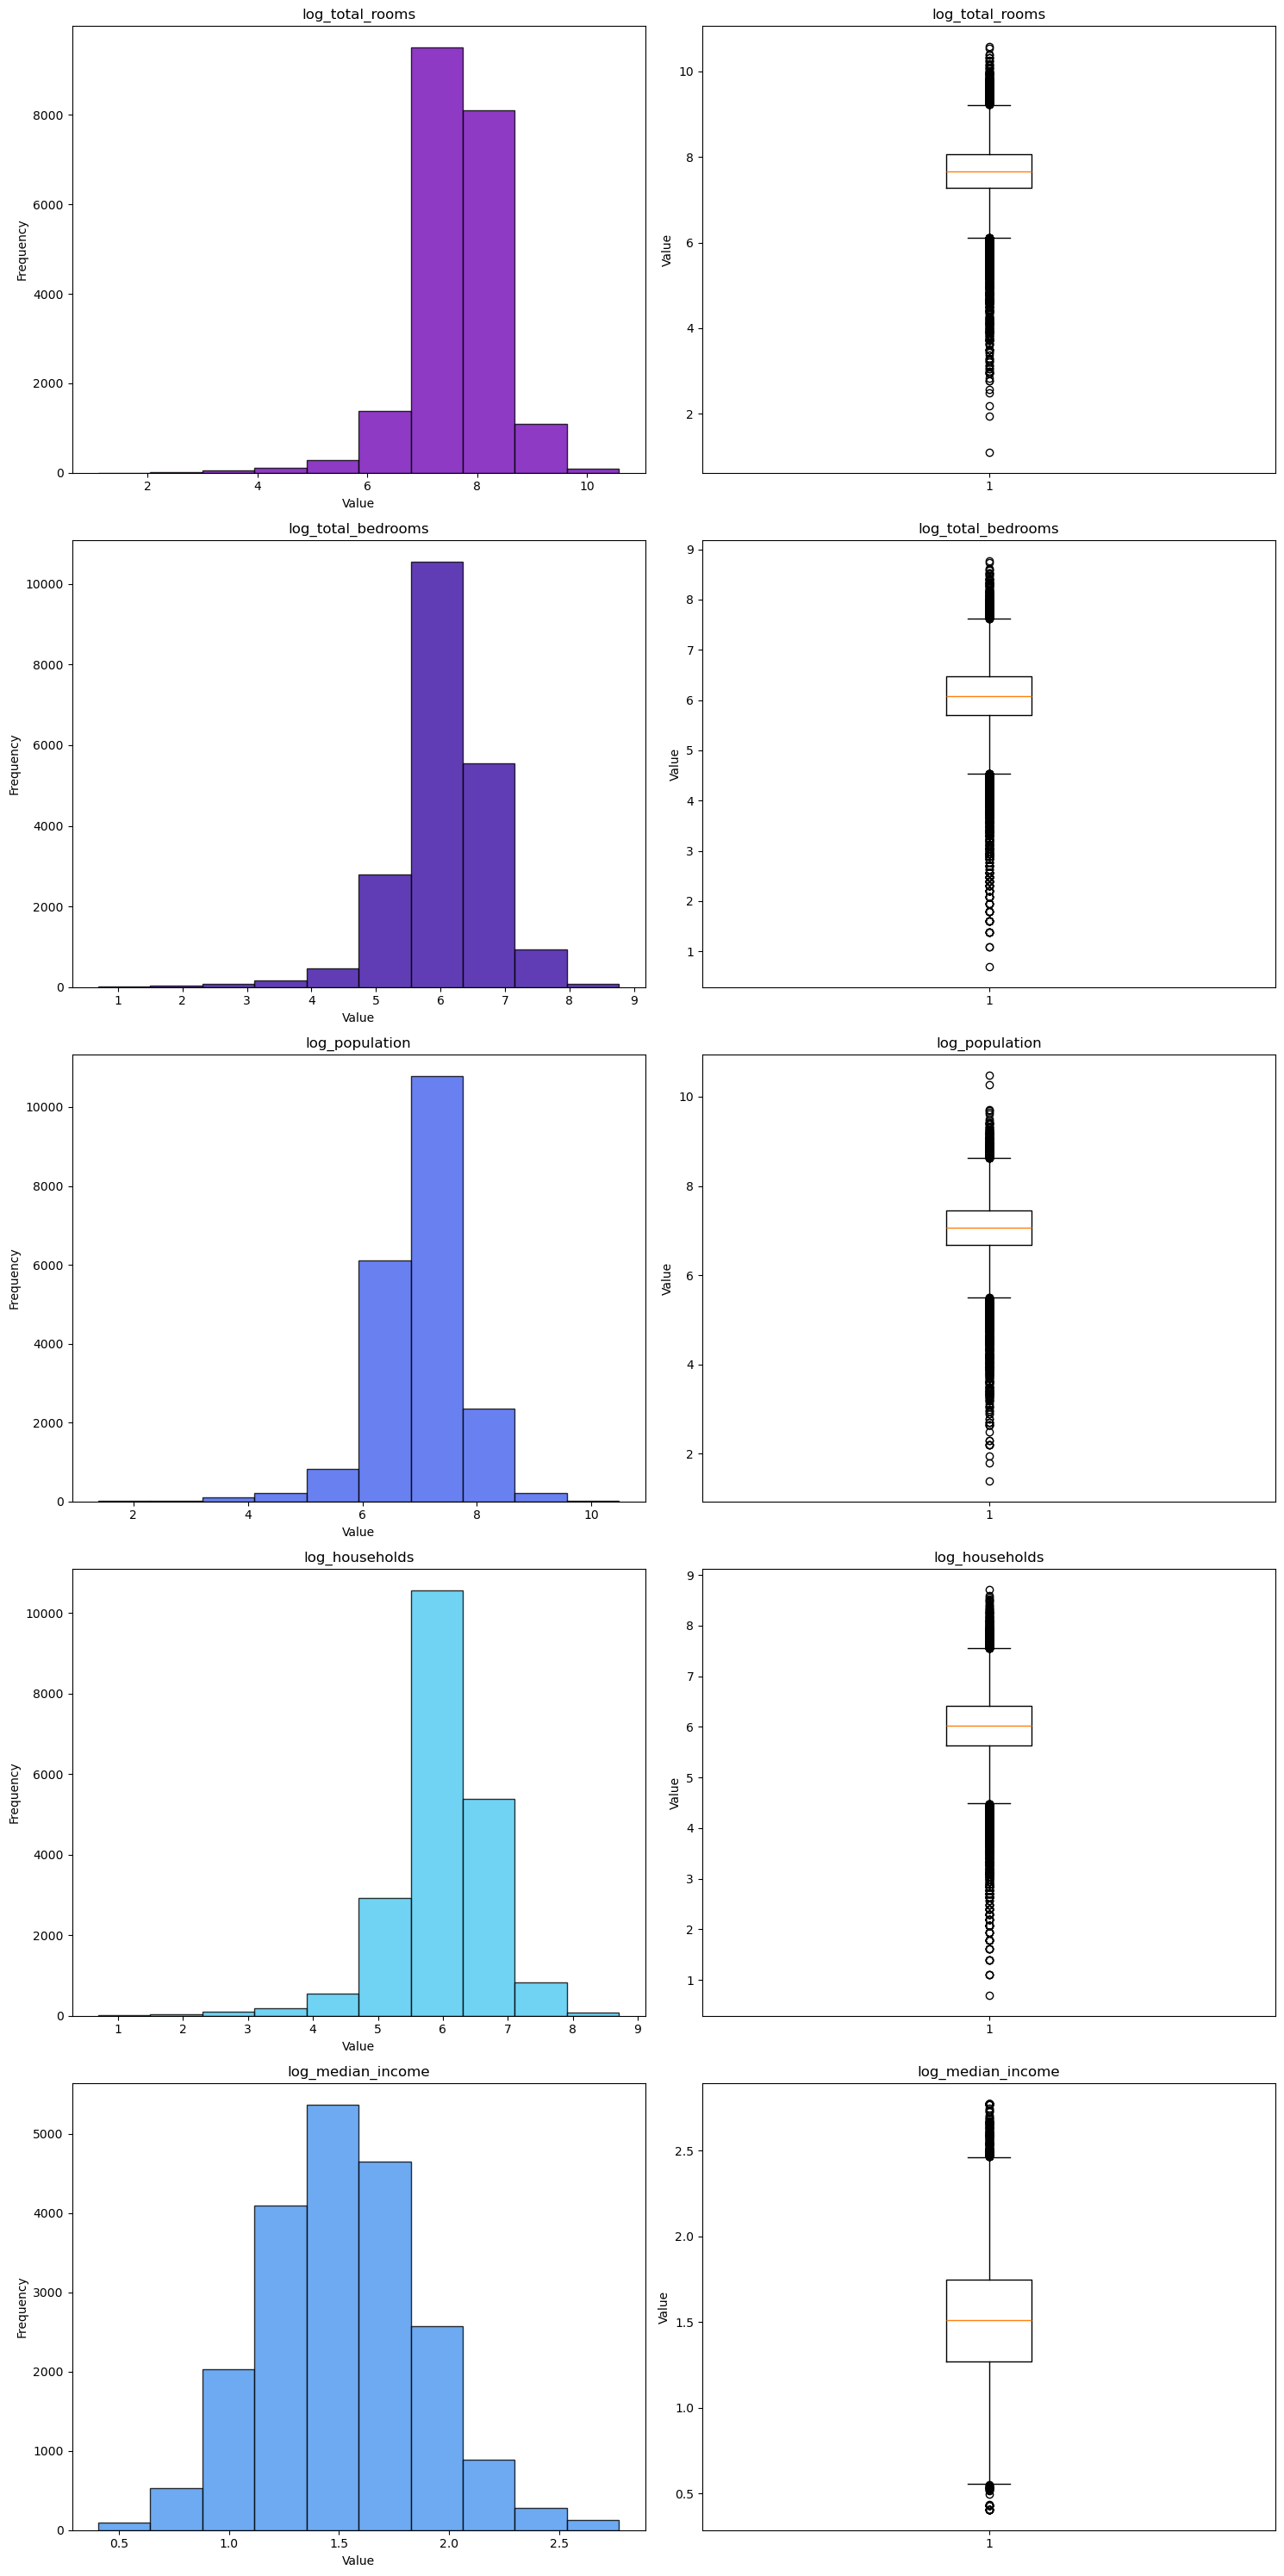

In [17]:
univariate_plot(data, 7, 12)

## Scaling Columns

In [18]:
data.head(1)

,longitude,latitude,housing_median_age,median_house_value,bedrooms_per_room,population_per_household,rooms_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households,log_median_income,<1h ocean,inland,near ocean,island
0,-122.23,37.88,41.0,452600.0,0.146591,2.555556,6.984127,6.781058,4.867534,5.777652,4.844187,2.23272,0,0,0,0


In [19]:
data, stats = standard_scaling(data, 0, 12,3)

In [20]:
#checking
data.describe()

,longitude,latitude,housing_median_age,median_house_value,bedrooms_per_room,population_per_household,rooms_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households,log_median_income,<1h ocean,inland,near ocean,island
count,2.064000e+04,2.064000e+04,2.064000e+04,20640.000000,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,20640.000000,20640.000000,20640.000000,20640.000000
mean,-8.592610e-15,2.269330e-15,6.609700e-17,206855.816909,1.542263e-16,3.786807e-18,7.711317e-17,-1.046536e-15,8.262125e-17,-9.501444e-16,7.711317e-16,-1.707506e-16,0.442636,0.317393,0.128779,0.000242
std,1.000000e+00,1.000000e+00,1.000000e+00,115395.615874,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.496710,0.465473,0.334963,0.015563
min,-2.385935e+00,-1.447533e+00,-2.196127e+00,14999.000000,-2.707251e+00,-2.289944e-01,-1.852274e+00,-8.707789e+00,-7.415233e+00,-7.659496e+00,-7.281218e+00,-3.099154e+00,0.000000,0.000000,0.000000,0.000000
25%,-1.113182e+00,-7.967694e-01,-8.453727e-01,119600.000000,-5.911186e-01,-6.170912e-02,-3.994399e-01,-4.678995e-01,-4.948911e-01,-4.835458e-01,-4.765767e-01,-6.866334e-01,0.000000,0.000000,0.000000,0.000000
50%,5.389006e-01,-6.422715e-01,2.864502e-02,179700.000000,-1.629927e-01,-2.431526e-02,-8.078293e-02,4.474857e-02,3.139900e-02,4.983314e-02,4.328229e-02,-1.453691e-02,0.000000,0.000000,0.000000,0.000000
75%,7.784775e-01,9.729330e-01,6.642943e-01,264725.000000,4.035696e-01,2.037404e-02,2.519554e-01,5.672913e-01,5.713745e-01,5.814146e-01,5.809197e-01,6.441170e-01,1.000000,1.000000,0.000000,0.000000
max,2.625216e+00,2.957996e+00,1.856137e+00,500001.000000,4.001463e+01,1.194162e+02,5.516190e+01,3.933563e+00,3.756548e+00,4.695397e+00,3.754506e+00,3.500638e+00,1.000000,1.000000,1.000000,1.000000


## Save the New DataSet

In [21]:
"""
training_set: 80%
testing_set: 20%
"""
split = int(0.8*len(data))

data.iloc[:split, :].to_csv('../data/processed/training_data.csv', index=False)
data.iloc[split:, :].to_csv('../data/processed/testing_data.csv', index=False)

## Preparing the Dataset for Binary Classification

Y ('median_house_value') is divided into 2 classes:

    cheap: less than 300K$
    expensive: greater than 300K$

In [22]:
data_copy = data.copy()
data_copy['median_house_value'] = binary_classification_formulation(data_copy['median_house_value'])

c:\Users\PC\Documents\House Prediction Project\src\clean.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_column.loc[cheap_mask]= 0
c:\Users\PC\Documents\House Prediction Project\src\clean.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_column.loc[expensive_mask] = 1


In [23]:
"""
training_set: 80%
testing_set: 20%
"""
split = int(0.8*len(data))

data_copy.iloc[:split, :].to_csv('../data/classification/binary/training_data.csv', index=False)
data_copy.iloc[split:, :].to_csv('../data/classification/binary/testing_data.csv', index=False)

## Preparing the Dataset for Classification (4 classes)

Y ('median_house_value') is divided into 4 classes: 

    cheap: less than 150K$
    moderate: between 150K$ and 250K$
    expensive: between 250K$ and 350K$
    very expensive: greater than 350K$
    

In [24]:
data['median_house_value'] = classification_formulation(data['median_house_value'] )

c:\Users\PC\Documents\House Prediction Project\src\clean.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_column.loc[cheap_mask]= "cheap"
c:\Users\PC\Documents\House Prediction Project\src\clean.py:69: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cheap' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  Y_column.loc[cheap_mask]= "cheap"


In [25]:
"""
training_set: 80%
testing_set: 20%
"""
split = int(0.8*len(data))

data.iloc[:split, :].to_csv('../data/classification/4_classes/training_data.csv', index=False)
data.iloc[split:, :].to_csv('../data/classification/4_classes/testing_data.csv', index=False)

## Store the Original Means and Standard Deviations

In [26]:
store={
    'means_stds': stats,
    'log_transformed_cols' : ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
}

with open('../cache/stats.pkl', 'wb') as f:
    pickle.dump(store, f)